# 08 - PU learning

In [28]:
ENV = 'colab'

from pathlib import Path

if ENV == 'colab':
    DATA_DIR = Path('/content/drive/MyDrive/thesis')
else:
    DATA_DIR = Path('00_data')

if ENV == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Reading

In [ ]:
import json
import re
import sys
import time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import lightgbm as lgb
from joblib import Parallel, delayed
from scipy.stats import spearmanr
from sentence_transformers import SentenceTransformer
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC
import cupy as cp

# PROJECT_ROOT = Path().resolve().parent
# sys.path.append(str(PROJECT_ROOT))

# from general.util.banned_words import add_flagged_column_vectorized

## Data

In [ ]:
non_drp = pd.read_parquet(str(DATA_DIR / '05_nondrp.parquet'))
drp = pd.read_parquet(str(DATA_DIR / '04_drp_in_dgf_nomic.parquet'))

In [ ]:
broad_unlabeled_dedup = non_drp.copy()
pu_pos = drp.copy()

In [ ]:
def normalize_title(t):
    if not t or not isinstance(t, str):
        return ''
    t = t.lower().strip()
    t = re.sub(r'[-/\\|_]+', ' ', t)
    t = re.sub(r'[^a-z0-9\s]', '', t)
    t = re.sub(r'\s+', ' ', t)
    return t

def clean_for_embedding_v2(text):
    if not text or not isinstance(text, str):
        return ''
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'&amp;', '&', text)
    text = re.sub(r'&lt;', '<', text)
    text = re.sub(r'&gt;', '>', text)
    text = re.sub(r'&quot;', '"', text)
    text = re.sub(r'&nbsp;', ' ', text)
    text = re.sub(r'&#?\w+;', ' ', text)
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'\b\w+\.(csv|xlsx|pdf|zip|json|xml|txt|doc)\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\b(div|span|quot|nbsp|href|rel|nofollow|noopener|noreferrer|ugc|src|img|alt|class|style)\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\b[a-zA-Z]{20,}\b', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# TF IDF based

## Convergence check

Random sample of 25k to check convergence

In [ ]:
RANDOM_SEED = 0
N_SAMPLE = 25_000

In [ ]:
random_baseline = broad_unlabeled_dedup.sample(n=N_SAMPLE, random_state=RANDOM_SEED)[['title', 'description', 'org_name', 'org_type']].reset_index(drop=True)

display(random_baseline)

,title,description,org_name,org_type
0,Elk Creek Seismic Waveforms 2010 (Part 3 of 7),Coal bursts (damaging seismic events in underg...,U.S. Department of Health & Human Services,Federal Government
1,"TIGER/Line Shapefile, Current, County, Donipha...",The TIGER/Line shapefiles and related database...,"U.S. Census Bureau, Department of Commerce",Federal Government
2,"TIGER/Line Shapefile, Current, County, Warrick...",This resource is a member of a series. The TIG...,"U.S. Census Bureau, Department of Commerce",Federal Government
3,ACF 2015-2016 Strategic Plan,ACF Agency Wide resource\n\nMetadata-only reco...,U.S. Department of Health & Human Services,Federal Government
4,"Friant Kern Canal At Woollomes Ave 3,5-Dichlor...","Measurements of 3,5-Dichlorobenzoic Acid colle...",Department of the Interior,Federal Government
...,...,...,...,...
24995,"TIGER/Line Shapefile, 2022, County, Gulf Count...",The TIGER/Line shapefiles and related database...,"U.S. Census Bureau, Department of Commerce",Federal Government
24996,"H10357: NOS Hydrographic Survey , Icy Strait, ...",The National Oceanic and Atmospheric Administr...,National Oceanic and Atmospheric Administratio...,Federal Government
24997,"TIGER/Line Shapefile, 2017, county, LaSalle C...",The TIGER/Line shapefiles and related database...,"U.S. Census Bureau, Department of Commerce",Federal Government
24998,"Walton-Smith CTD, WS0919, WS0919_WS0919_023, 2...","Walton-Smith Conductivity, Temperature, Depth ...",National Oceanic and Atmospheric Administratio...,Federal Government


to check how many iterations are needed

In [ ]:
title_embs = np.array(pu_pos['title_embeddings_nomic'].tolist(), dtype=np.float32)
desc_embs = np.array(pu_pos['desc_embeddings_nomic'].tolist(),  dtype=np.float32)
X_pos = np.hstack([title_embs, desc_embs])
X_pos.shape

(1313, 1536)

In [ ]:
diag_sample = broad_unlabeled_dedup.sample(
    n=min(20 * len(pu_pos), len(broad_unlabeled_dedup)),
    random_state=42,
).reset_index(drop=True)

In [ ]:
title_embs = np.array(diag_sample['title_embeddings_nomic'].tolist(), dtype=np.float32)
desc_embs = np.array(diag_sample['desc_embeddings_nomic'].tolist(),  dtype=np.float32)
X_diag = np.hstack([title_embs, desc_embs])
print(f'X_diag shape: {X_diag.shape}  dtype={X_diag.dtype}')

X_diag shape: (26260, 1536)  dtype=float32


In [ ]:
def pu_convergence_diagnostic(X_pos, X_unl, max_iter=50, check_every=5, top_k=100, random_state=42):
    rng = np.random.default_rng(random_state)
    n_pos = len(X_pos)
    running = np.zeros(len(X_unl))
    prev_scores = None
    prev_top_k  = None
    rows = []

    for it in range(1, max_iter + 1):
        unl_idx = rng.choice(len(X_unl), size=n_pos, replace=False)
        X_tr = np.vstack([X_pos, X_unl[unl_idx]])
        y_tr = np.array([1] * n_pos + [0] * n_pos)

        clf = SVC(kernel='linear', C=1.0, probability=True)
        clf.fit(X_tr, y_tr)
        running = (running * (it - 1) + clf.predict_proba(X_unl)[:, 1]) / it

        if it % check_every == 0 or it == 1:
            current_top = set(np.argsort(running)[::-1][:top_k])
            rmse = float(np.sqrt(np.mean((running - prev_scores) ** 2))) if prev_scores is not None else float('nan')
            jaccard = len(current_top & prev_top_k) / top_k if prev_top_k is not None else float('nan')
            rows.append({'n_bags': it, 'score_rmse': rmse, f'top{top_k}_jaccard': jaccard})
            print(f'  iter {it:3d} | RMSE={rmse:.5f} | top-{top_k} Jaccard={jaccard:.3f}')
            prev_scores = running.copy()
            prev_top_k  = current_top

    return pd.DataFrame(rows)


In [ ]:
conv_df = pu_convergence_diagnostic(X_pos, X_diag, max_iter=200, check_every=5, top_k=100)
display(conv_df)

  iter   1 | RMSE=nan | top-100 Jaccard=nan
  iter   5 | RMSE=0.05267 | top-100 Jaccard=0.750
  iter  10 | RMSE=0.01692 | top-100 Jaccard=0.910
  iter  15 | RMSE=0.00992 | top-100 Jaccard=0.970
  iter  20 | RMSE=0.00631 | top-100 Jaccard=0.980
  iter  25 | RMSE=0.00556 | top-100 Jaccard=0.970
  iter  30 | RMSE=0.00397 | top-100 Jaccard=0.980
  iter  35 | RMSE=0.00340 | top-100 Jaccard=0.980
  iter  40 | RMSE=0.00320 | top-100 Jaccard=0.990
  iter  45 | RMSE=0.00259 | top-100 Jaccard=0.990
  iter  50 | RMSE=0.00255 | top-100 Jaccard=0.970
  iter  55 | RMSE=0.00218 | top-100 Jaccard=0.980
  iter  60 | RMSE=0.00197 | top-100 Jaccard=0.990
  iter  65 | RMSE=0.00206 | top-100 Jaccard=1.000
  iter  70 | RMSE=0.00181 | top-100 Jaccard=0.980
  iter  75 | RMSE=0.00179 | top-100 Jaccard=0.980
  iter  80 | RMSE=0.00155 | top-100 Jaccard=1.000
  iter  85 | RMSE=0.00133 | top-100 Jaccard=0.990
  iter  90 | RMSE=0.00135 | top-100 Jaccard=0.990
  iter  95 | RMSE=0.00125 | top-100 Jaccard=0.990
  iter

,n_bags,score_rmse,top100_jaccard
0,1,NaN,NaN
1,5,0.052667,0.75
2,10,0.016923,0.91
3,15,0.009917,0.97
4,20,0.006308,0.98
5,25,0.005558,0.97
6,30,0.003968,0.98
7,35,0.003398,0.98
8,40,0.003199,0.99
9,45,0.002585,0.99


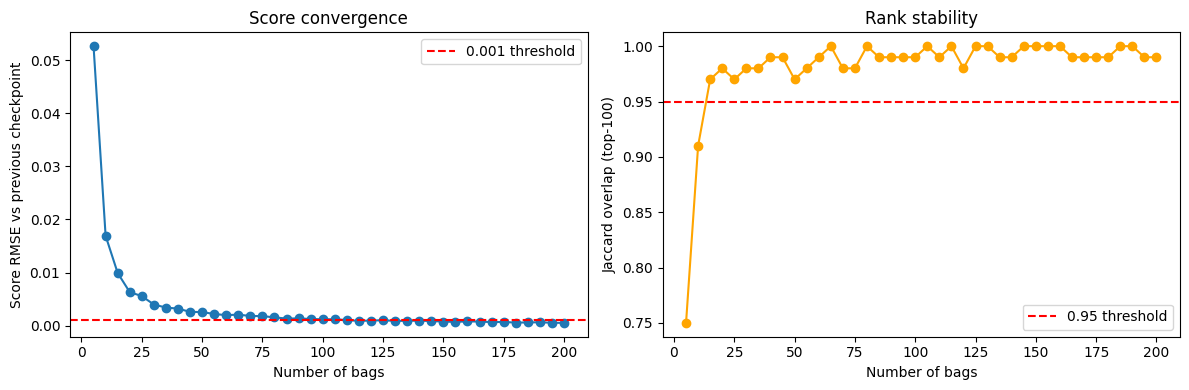

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(conv_df['n_bags'], conv_df['score_rmse'], marker='o')
ax1.set_xlabel('Number of bags')
ax1.set_ylabel('Score RMSE vs previous checkpoint')
ax1.set_title('Score convergence')
ax1.axhline(0.001, color='red', linestyle='--', label='0.001 threshold')
ax1.legend()

ax2.plot(conv_df['n_bags'], conv_df['top100_jaccard'], marker='o', color='orange')
ax2.set_xlabel('Number of bags')
ax2.set_ylabel('Jaccard overlap (top-100)')
ax2.set_title('Rank stability')
ax2.axhline(0.95, color='red', linestyle='--', label='0.95 threshold')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
stable = conv_df[(conv_df['score_rmse'] < 0.001) & (conv_df['top100_jaccard'] >= 0.95)]
if len(stable):
    print(f'first iteration meeting both thresholds: {int(stable['n_bags'].iloc[0])}')
else:
    print('no iteration met the thresholds')

first iteration meeting both thresholds: 115


## Full run

In [ ]:
N_SAMPLE_PU = len(broad_unlabeled_dedup)
RANDOM_SEED = 0
N_PU_ITER = 115

In [ ]:
pu_sample = broad_unlabeled_dedup.sample(n=min(N_SAMPLE_PU, len(broad_unlabeled_dedup)), random_state=RANDOM_SEED).reset_index(drop=True)

print(f'positives: {len(pu_pos)}')
print(f'sample: {len(pu_sample)}')

positives: 1313
sample: 268100


In [ ]:
def make_all_text(df):
    return (df['title'].fillna('').astype(str) + ' ' + df['description'].fillna('').astype(str)).str.strip()

In [ ]:
pos_train, pos_holdout = train_test_split(pu_pos, test_size=0.2, random_state=42)

pos_train_text = make_all_text(pos_train)
pos_holdout_text = make_all_text(pos_holdout)
sample_text = make_all_text(pu_sample)

vec_tfidf = TfidfVectorizer(max_features=10_000, ngram_range=(1, 2), sublinear_tf=True, stop_words='english')
vec_tfidf.fit(pd.concat([pos_train_text, sample_text], ignore_index=True))
print(f'vocal size: {len(vec_tfidf.vocabulary_)}')

vocal size: 10000


In [ ]:
X_pos_train_tfidf = vec_tfidf.transform(pos_train_text)
X_pos_holdout_tfidf = vec_tfidf.transform(pos_holdout_text)
X_tfidf_sample = vec_tfidf.transform(sample_text)

print(f'train: {X_pos_train_tfidf.shape}  nnz={X_pos_train_tfidf.nnz:,}')
print(f'holdout: {X_pos_holdout_tfidf.shape}  nnz={X_pos_holdout_tfidf.nnz:,}')
print(f'full sample: {X_tfidf_sample.shape}  nnz={X_tfidf_sample.nnz:,}')


train: (1050, 10000)  nnz=63,740
holdout: (263, 10000)  nnz=16,542
full sample: (268100, 10000)  nnz=28,364,095


In [ ]:
def pu_bag(bag_seed, X_pos_train, X_pos_holdout, X_unl, unl_idx, n_proxy, C):
    rng = np.random.default_rng(bag_seed)
    sampled_unl = rng.choice(unl_idx, size=n_proxy, replace=False)
    holdout = np.setdiff1d(unl_idx, sampled_unl, assume_unique=True)

    X_train = sp.vstack([X_pos_train, X_unl[sampled_unl]])
    y_train = np.array([1] * n_proxy + [0] * n_proxy)

    clf = SVC(kernel='linear', C=C, probability=True)
    clf.fit(X_train, y_train)

    return (holdout, clf.predict_proba(X_unl[holdout])[:, 1], clf.predict_proba(X_pos_holdout)[:, 1])


def pu_bag_gpu(bag_seed, X_pos_train_gpu, X_pos_holdout_gpu, X_unl_gpu, unl_idx, n_proxy, C):
    from cuml.svm import SVC as cuSVC
    import cupy as cp

    rng = np.random.default_rng(bag_seed)
    sampled_unl = rng.choice(unl_idx, size=n_proxy, replace=False)
    holdout = np.setdiff1d(unl_idx, sampled_unl, assume_unique=True)

    X_train = cp.vstack([X_pos_train_gpu, X_unl_gpu[sampled_unl]])
    y_train = cp.asarray([1] * n_proxy + [0] * n_proxy, dtype=cp.float32)

    clf = cuSVC(kernel='linear', C=C, probability=True)
    clf.fit(X_train, y_train)

    return (holdout, cp.asnumpy(clf.predict_proba(X_unl_gpu[holdout])[:, 1]), cp.asnumpy(clf.predict_proba(X_pos_holdout_gpu)[:, 1]))


def bagged_pu_scores_tfidf(X_pos_train, X_pos_holdout, X_unl, n_estimators=100, C=1.0, random_state=42, n_jobs=-1, use_gpu=False):
    rng = np.random.default_rng(random_state)
    unl_idx = np.arange(X_unl.shape[0])
    n_proxy = X_pos_train.shape[0]
    seeds = rng.integers(0, 2**31, size=n_estimators).tolist()

    pu_scores = np.zeros(X_unl.shape[0])
    pu_counts = np.zeros(X_unl.shape[0], dtype=int)
    holdout_scores = np.zeros(X_pos_holdout.shape[0])

    if use_gpu:
        print('gpu')
        X_pos_train_gpu = cp.asarray(X_pos_train.toarray(),   dtype=cp.float32)
        X_pos_holdout_gpu = cp.asarray(X_pos_holdout.toarray(), dtype=cp.float32)
        X_unl_gpu = cp.asarray(X_unl.toarray(),         dtype=cp.float32)
        print(f'  done, running {n_estimators} bags')

        for i, s in enumerate(seeds):
            holdout, unl_proba, pos_proba = pu_bag_gpu(
                s, X_pos_train_gpu, X_pos_holdout_gpu, X_unl_gpu, unl_idx, n_proxy, C)
            pu_scores[holdout] += unl_proba
            pu_counts[holdout] += 1
            holdout_scores     += pos_proba
            if (i + 1) % 10 == 0:
                print(f'  bag {i+1}/{n_estimators}')
    else:
        job_iter = Parallel(n_jobs=n_jobs, return_as='generator')(delayed(pu_bag)(s, X_pos_train, X_pos_holdout, X_unl, unl_idx, n_proxy, C)
            for s in seeds
        )
        for i, (holdout, unl_proba, pos_proba) in enumerate(job_iter):
            pu_scores[holdout] += unl_proba
            pu_counts[holdout] += 1
            holdout_scores     += pos_proba
            if (i + 1) % 10 == 0:
                print(f'bag {i+1}/{n_estimators}')

    fallback = pu_scores[pu_counts > 0].mean() if (pu_counts > 0).any() else 0.0
    final = np.divide(pu_scores, pu_counts, out=np.full_like(pu_scores, fallback), where=pu_counts > 0)
    holdout_avg = holdout_scores / n_estimators

    print(f'Holdout ({X_pos_holdout.shape[0]} records):')
    print(f' mean: {holdout_avg.mean():.3f}')
    print(f' median: {np.median(holdout_avg):.3f}')
    print(f' >0.60 (High tier): {(holdout_avg > 0.60).mean():.1%}')
    print(f' >0.35 (Medium+): {(holdout_avg > 0.35).mean():.1%}')

    return final, pu_counts, holdout_avg


In [ ]:
print(f'pos train: {X_pos_train_tfidf.shape[0]:,}, pos holdout: {X_pos_holdout_tfidf.shape[0]:,}')
print(f'candidate pool: {X_tfidf_sample.shape[0]:,}, proxy neg per bag: {X_pos_train_tfidf.shape[0]:,} (1:1)')

tfidf_pu_scores, tfidf_pu_counts, tfidf_holdout_eval = bagged_pu_scores_tfidf(X_pos_train_tfidf, X_pos_holdout_tfidf, X_tfidf_sample, n_estimators=N_PU_ITER, use_gpu=True)

print(f'records never in holdout: {(tfidf_pu_counts == 0).sum()}')


pos train: 1,050, pos holdout: 263
candidate pool: 268,100, proxy neg per bag: 1,050 (1:1)
gpu
  done, running 115 bags
  bag 10/115
  bag 20/115
  bag 30/115
  bag 40/115
  bag 50/115
  bag 60/115
  bag 70/115
  bag 80/115
  bag 90/115
  bag 100/115
  bag 110/115
Holdout (263 records):
 mean: 0.931
 median: 0.991
 >0.60 (High tier): 93.5%
 >0.35 (Medium+): 97.7%
records never in holdout: 0


In [ ]:
np.save(str(DATA_DIR /'tfidf_pu_scores.npy'), tfidf_pu_scores)
np.save(str(DATA_DIR /'tfidf_pu_counts2.npy'), tfidf_pu_counts)
np.save(str(DATA_DIR /'tfidf_holdout_eval2.npy'), tfidf_holdout_eval)

In [ ]:
tfidf_pu_scores = np.load(str(DATA_DIR /'tfidf_pu_scores.npy'))
tfidf_pu_counts = np.load(str(DATA_DIR /'tfidf_pu_counts2.npy'))
tfidf_holdout_eval = np.load(str(DATA_DIR /'tfidf_holdout_eval2.npy'))

In [ ]:
print(f'mean={tfidf_holdout_eval.mean():.3f}  median={np.median(tfidf_holdout_eval):.3f}')

mean=0.931  median=0.991


scores on the holdout positives

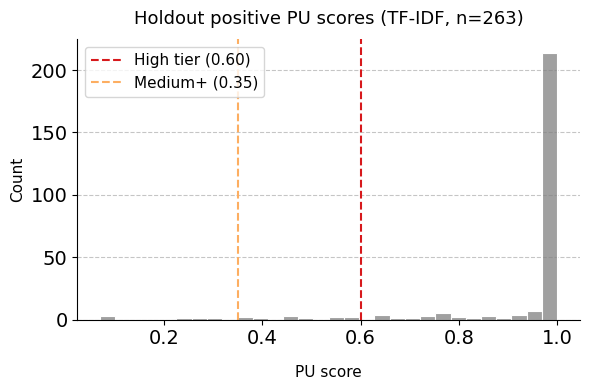

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(tfidf_holdout_eval, bins=30, color='grey', edgecolor='white', linewidth=0.8, ax=ax)
ax.axvline(0.60, color='#d7191c', linestyle='--', label='High tier (0.60)')
ax.axvline(0.35, color='#fdae61', linestyle='--', label='Medium+ (0.35)')
ax.set_xlabel('PU score', fontsize=11, labelpad=12)
ax.set_ylabel('Count', fontsize=11)
ax.set_title(f'Holdout positive PU scores (TF-IDF, n={len(tfidf_holdout_eval)})',
             fontsize=13, pad=11)
ax.tick_params(axis='both', labelsize=14)
ax.yaxis.grid(True, linestyle='--', alpha=0.45, color='grey')
ax.set_axisbelow(True)
ax.legend(fontsize=11, loc='upper left')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
holdout_df = pos_holdout.copy().reset_index(drop=True)
holdout_df['holdout_pu_score'] = tfidf_holdout_eval

cols = [c for c in ['title', 'description', 'org_name', 'org_type'] if c in holdout_df.columns]

missed = holdout_df[holdout_df['holdout_pu_score'] < 0.35].sort_values('holdout_pu_score')
low_conf = holdout_df[(holdout_df['holdout_pu_score'] >= 0.35) & (holdout_df['holdout_pu_score'] < 0.60)].sort_values('holdout_pu_score')

print(f'false negatives (below medium tier):  {len(missed)}')
print(f'low confidence medium tier: {len(low_conf)}\n')

print('< 0.35')
display(missed[['holdout_pu_score'] + cols].head(20))


false negatives (below medium tier):  6
low confidence medium tier: 11

< 0.35


,holdout_pu_score,title,description,org_name,org_type
190,0.070604,"Metabolic Rate, Body Composition, Foraging Suc...",This data package includes 5 child items with ...,Department of the Interior,Federal Government
79,0.080842,FOIA Logs,Log files published by the Office of FOIA Serv...,Securities and Exchange Commission,Federal Government
58,0.093854,FOIA Electronic Reading Room,The E-FOIA Amendments of 1996 require that fre...,US International Trade Commission,Federal Government
240,0.230300,AmeriCorps Research Grantee Story Map: April 2024,The AmeriCorps Research Grantee Story Map is d...,AmeriCorps,Federal Government
174,0.284335,VA All Employee Survey (AES),VA All Employee Survey data page,Department of Veterans Affairs,Federal Government
0,0.311453,Food Insecurity Hotspots Data Set,The Food Insecurity Hotspots Data Set consists...,National Aeronautics and Space Administration,Federal Government


## Evaluation

tiers
* high >0.6
* medium 0.35 - 0.6
* low <0.35

In [29]:
centroid = np.asarray(X_pos_train_tfidf.mean(axis=0))
centroid_sims = cosine_similarity(X_tfidf_sample, centroid).ravel()

pu_broad_ranked = broad_unlabeled_dedup[['title', 'description', 'org_name', 'org_type', 'title_norm']].copy()
pu_broad_ranked['pu_score']     = tfidf_pu_scores
pu_broad_ranked['centroid_sim'] = centroid_sims
pu_broad_ranked = pu_broad_ranked.sort_values('pu_score', ascending=False).reset_index(drop=True)

bins = [-np.inf, 0.35, 0.60, np.inf]
labels = ['Low', 'Medium', 'High']
pu_broad_ranked['review_tier'] = pd.cut(pu_broad_ranked['pu_score'], bins=bins, labels=labels)

print('top 25 candidates:')
display(pu_broad_ranked[['review_tier', 'pu_score', 'centroid_sim', 'org_name', 'title']].head(25))


top 25 candidates:


,review_tier,pu_score,centroid_sim,org_name,title
0,High,0.999952,0.354013,National Oceanic and Atmospheric Administratio...,Benthic Surveys in Nu'uuli Pala Lagoon and Bac...
1,High,0.999950,0.273598,National Oceanic and Atmospheric Administratio...,NOAA/WDS Paleoclimatology - Touchan - Tazaot -...
2,High,0.999913,0.277620,Department of the Interior,Mineral Commodity Summaries 2022 - CADMIUM Dat...
3,High,0.999897,0.323027,Department of the Interior,Field data for the Vegetation Mapping Inventor...
4,High,0.999886,0.334505,Department of the Interior,Continuous Records of Shallow Soil Temperature...
5,High,0.999855,0.453056,"U.S. Census Bureau, Department of Commerce","TIGER/Line Shapefile, 2017, county, Mecklenbu..."
6,High,0.999850,0.336283,National Oceanic and Atmospheric Administratio...,"Chemical, physical, profile and laboratory ana..."
7,High,0.999846,0.290116,U.S. Environmental Protection Agency,2018 CSMI LAKE ONTARIO LOWER FOOD AQUATIC WEB ...
8,High,0.999754,0.362966,National Oceanic and Atmospheric Administratio...,"F00912: NOS Hydrographic Survey , 2024-10-15"
9,High,0.999744,0.338161,Department of Veterans Affairs,Insurance Death Awards (Amount) by Fiscal Year


In [30]:
print('score distribution:')
print(pu_broad_ranked['pu_score'].describe().round(3))

score distribution:
count    268100.000
mean          0.076
std           0.163
min           0.002
25%           0.012
50%           0.017
75%           0.049
max           1.000
Name: pu_score, dtype: float64


In [31]:
print(pu_broad_ranked['review_tier'].value_counts().sort_index())

review_tier
Low       251804
Medium      7702
High        8594
Name: count, dtype: int64


In [32]:
pool_summary = pd.DataFrame([{
    'pool': 'broad (random sample)',
    'known_positives': len(pu_pos),
    'candidate_pool': len(pu_broad_ranked),
    'high_priority': int((pu_broad_ranked['review_tier'] == 'High').sum()),
    'median_pu_score': round(pu_broad_ranked['pu_score'].median(), 3),
    'p90_pu_score': round(pu_broad_ranked['pu_score'].quantile(0.90), 3),
}])

display(pool_summary)

,pool,known_positives,candidate_pool,high_priority,median_pu_score,p90_pu_score
0,broad (random sample),1313,268100,8594,0.017,0.19


In [33]:
tier_sum = (
    pu_broad_ranked.groupby('review_tier', observed=False)
    .agg(
        n_candidates = ('title', 'size'),
        median_pu = ('pu_score', 'median'),
        p90_pu  = ('pu_score', lambda x: x.quantile(0.90)),
        median_csim = ('centroid_sim', 'median'),
        n_agencies = ('org_name', 'nunique'),
    )
    .reset_index()
    .sort_values('median_pu', ascending=False)
    .round(3)
)

display(tier_sum)

,review_tier,n_candidates,median_pu,p90_pu,median_csim,n_agencies
2,High,8594,0.807,0.979,0.111,78
1,Medium,7702,0.453,0.567,0.082,74
0,Low,251804,0.016,0.105,0.041,103


agency breakdown in high prioritu

In [34]:
high = pu_broad_ranked[pu_broad_ranked['review_tier'] == 'High']

print(f'high-priority cand {len(high)}  in {high['org_name'].nunique()} agencies\n')
display(
    high['org_name']
    .value_counts()
    .head(15)
    .rename_axis('agency')
    .reset_index(name='n_candidates')
)

high-priority cand 8594  in 78 agencies



,agency,n_candidates
0,National Oceanic and Atmospheric Administratio...,2517
1,"U.S. Census Bureau, Department of Commerce",2086
2,Department of the Interior,1312
3,National Aeronautics and Space Administration,698
4,U.S. Department of Health & Human Services,539
5,U.S. Environmental Protection Agency,237
6,Department of Energy,116
7,State of California,113
8,Department of Agriculture,100
9,Department of Justice,65


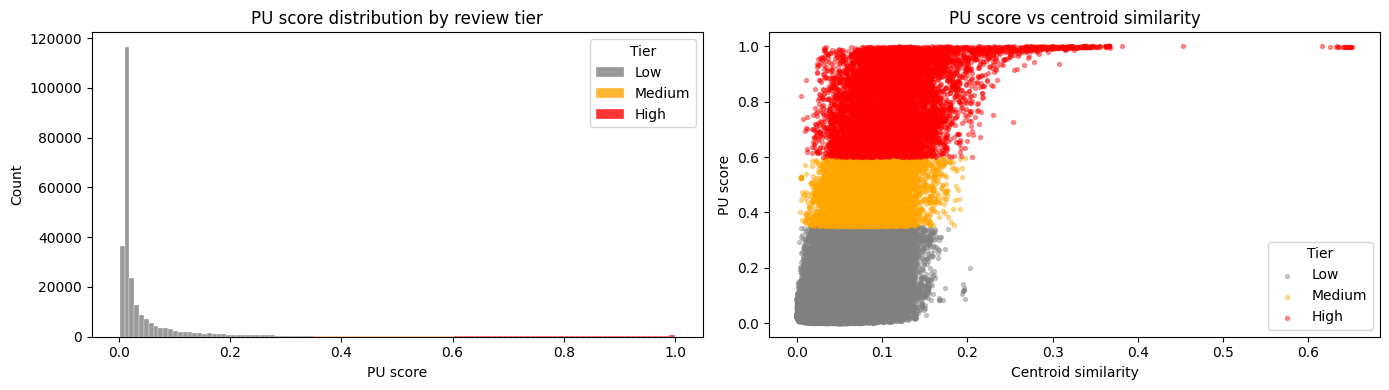

PU score ≥ 0.50: 11,107 records  (4.1%)
PU score ≥ 0.60: 8,594 records  (3.2%)
PU score ≥ 0.70: 6,419 records  (2.4%)
PU score ≥ 0.80: 4,410 records  (1.6%)


In [35]:
tier_colours = {'Low': 'grey', 'Medium': 'orange', 'High': 'red'}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for tier, colour in tier_colours.items():
    subset = pu_broad_ranked.loc[pu_broad_ranked['review_tier'] == tier, 'pu_score']
    axes[0].hist(subset, bins=40, color=colour, alpha=0.8, label=tier, edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('PU score')
axes[0].set_ylabel('Count')
axes[0].set_title('PU score distribution by review tier')
axes[0].legend(title='Tier')

for tier, colour in tier_colours.items():
    subset = pu_broad_ranked[pu_broad_ranked['review_tier'] == tier]
    axes[1].scatter(subset['centroid_sim'], subset['pu_score'],
                    c=colour, alpha=0.4, s=8, label=tier)
axes[1].set_xlabel('Centroid similarity')
axes[1].set_ylabel('PU score')
axes[1].set_title('PU score vs centroid similarity')
axes[1].legend(title='Tier')

plt.tight_layout()
plt.show()

for t in [0.50, 0.60, 0.70, 0.80]:
    n = (pu_broad_ranked['pu_score'] >= t).sum()
    print(f'PU score ≥ {t:.2f}: {n:,} records  ({n/len(pu_broad_ranked):.1%})')

In [36]:
from sklearn.metrics.pairwise import cosine_similarity as _cos

X_pos_tfidf_all = vec_tfidf.transform(make_all_text(pu_pos))
sims_to_pos = _cos(X_tfidf_sample, X_pos_tfidf_all)   # (n_cand, n_pos)
nn_idx = sims_to_pos.argmax(axis=1)
nn_sim = sims_to_pos.max(axis=1)

pu_broad_ranked['nn_max_sim'] = nn_sim[pu_broad_ranked.index]
pu_broad_ranked['nearest_positive'] = [pu_pos.iloc[i]['title'] for i in nn_idx[pu_broad_ranked.index]]
pu_broad_ranked['nearest_pos_org']  = [pu_pos.iloc[i].get('org_name', '') for i in nn_idx[pu_broad_ranked.index]]

top10 = pu_broad_ranked.head(10).copy()
top10['desc_snippet'] = pu_broad_ranked['description'].fillna('').str[:200] + '...'

for _, row in top10.iterrows():
    print()
    print(f'[{row["review_tier"]}]  PU={row["pu_score"]:.3f}  centroid_sim={row["centroid_sim"]:.3f}  nn_sim={row["nn_max_sim"]:.3f}')
    print(f'Agency:   {row["org_name"]}')
    print(f'Title:    {row["title"]}')
    print(f'Nearest+: {row["nearest_positive"]}  ({row["nearest_pos_org"]})')
    print(f'Desc:     {row["desc_snippet"]}')
    print()



[High]  PU=1.000  centroid_sim=0.354  nn_sim=0.092
Agency:   National Oceanic and Atmospheric Administration, Department of Commerce
Title:    Benthic Surveys in Nu'uuli Pala Lagoon and Backreef in American Samoa: comprehensive assessment of coral demography (adult and juvenile corals) from belt transect surveys from 2024-11-11 to 2024-11-21
Nearest+: Development of an Empirically Derived Measure of Food Safety Culture in Restaurants  (U.S. Department of Health & Human Services)
Desc:     This metadata record describes the coral demographic data of Nu'uuli Pala Lagoon and Backreef, American Samoa. Surveys were conducted by snorkelers from the Ecosystem Sciences Division (ESD) of the NO...


[High]  PU=1.000  centroid_sim=0.274  nn_sim=0.051
Agency:   National Oceanic and Atmospheric Administration, Department of Commerce
Title:    NOAA/WDS Paleoclimatology - Touchan - Tazaot - ABMA - ITRDB MAR045
Nearest+: Hydrocarbon Gas Liquids (HGL) Pipelines  (Department of Transportation)
Desc:  

In [37]:
for tier in ['High', 'Medium', 'Low']:
    sub = pu_broad_ranked[pu_broad_ranked['review_tier'] == tier]
    frac = (sub['nn_max_sim'] > 0.70).mean()
    print(f'{tier:8s}: {frac:.1%} of candidates have nn_max_sim > 0.70 to a known positive')

High    : 0.4% of candidates have nn_max_sim > 0.70 to a known positive
Medium  : 0.3% of candidates have nn_max_sim > 0.70 to a known positive
Low     : 0.4% of candidates have nn_max_sim > 0.70 to a known positive


# Embedding based

In [38]:
pos_train, pos_holdout = train_test_split(pu_pos, test_size=0.2, random_state=42)

In [39]:
title_embs = np.array(pos_train['title_embeddings_nomic'].tolist(), dtype=np.float32)
desc_embs = np.array(pos_train['desc_embeddings_nomic'].tolist(),  dtype=np.float32)
X_pos_train = np.hstack([title_embs, desc_embs])
print(f'X_pos_train shape: {X_pos_train.shape}  dtype={X_pos_train.dtype}')

X_pos_train shape: (1050, 1536)  dtype=float32


In [40]:
title_embs = np.array(pos_holdout['title_embeddings_nomic'].tolist(), dtype=np.float32)
desc_embs = np.array(pos_holdout['desc_embeddings_nomic'].tolist(),  dtype=np.float32)
X_pos_holdout = np.hstack([title_embs, desc_embs])
print(f'X_pos_holdout shape: {X_pos_holdout.shape}  dtype={X_pos_holdout.dtype}')

X_pos_holdout shape: (263, 1536)  dtype=float32


In [44]:
title_embs = np.array(pu_sample['title_embeddings_nomic'].tolist(), dtype=np.float32)
desc_embs  = np.array(pu_sample['desc_embeddings_nomic'].tolist(),  dtype=np.float32)
X_sample   = np.hstack([title_embs, desc_embs])
print(f'X_sample shape: {X_sample.shape}  dtype={X_sample.dtype}')

X_sample shape: (268100, 1536)  dtype=float32


In [45]:
def _pu_bag_emb(bag_seed, X_pos_train, X_pos_holdout, X_unl, unl_idx, n_proxy, C):
    rng = np.random.default_rng(bag_seed)
    sampled_unl = rng.choice(unl_idx, size=n_proxy, replace=False)
    holdout = np.setdiff1d(unl_idx, sampled_unl, assume_unique=True)

    X_train = np.vstack([X_pos_train, X_unl[sampled_unl]])
    y_train = np.array([1] * n_proxy + [0] * n_proxy)

    clf = SVC(kernel='linear', C=C, probability=True)
    clf.fit(X_train, y_train)

    return (holdout,
            clf.predict_proba(X_unl[holdout])[:, 1],
            clf.predict_proba(X_pos_holdout)[:, 1])


def _pu_bag_emb_gpu(bag_seed, X_pos_train_gpu, X_pos_holdout_gpu, X_unl_gpu, unl_idx, n_proxy, C):
    '''All X arguments are already cupy arrays — no conversion per bag.'''
    from cuml.svm import SVC as cuSVC
    import cupy as cp

    rng = np.random.default_rng(bag_seed)
    sampled_unl = rng.choice(unl_idx, size=n_proxy, replace=False)
    holdout = np.setdiff1d(unl_idx, sampled_unl, assume_unique=True)

    X_train = cp.vstack([X_pos_train_gpu, X_unl_gpu[sampled_unl]])
    y_train = cp.asarray([1] * n_proxy + [0] * n_proxy, dtype=cp.float32)

    clf = cuSVC(kernel='linear', C=C, probability=True)
    clf.fit(X_train, y_train)

    return (holdout,
            cp.asnumpy(clf.predict_proba(X_unl_gpu[holdout])[:, 1]),
            cp.asnumpy(clf.predict_proba(X_pos_holdout_gpu)[:, 1]))


def bagged_pu_scores_with_holdout(X_pos_train, X_pos_holdout, X_unl,
                                   n_estimators=100, C=1.0, random_state=42, n_jobs=-1, use_gpu=False):
    rng = np.random.default_rng(random_state)
    unl_idx = np.arange(len(X_unl))
    n_proxy = len(X_pos_train)
    seeds = rng.integers(0, 2**31, size=n_estimators).tolist()

    pu_scores = np.zeros(len(X_unl))
    pu_counts = np.zeros(len(X_unl), dtype=int)
    holdout_scores = np.zeros(len(X_pos_holdout))

    if use_gpu:
        import cupy as cp
        print('gpu')
        X_pos_train_gpu   = cp.asarray(X_pos_train,   dtype=cp.float32)
        X_pos_holdout_gpu = cp.asarray(X_pos_holdout, dtype=cp.float32)
        X_unl_gpu         = cp.asarray(X_unl,         dtype=cp.float32)

        for i, s in enumerate(seeds):
            holdout, unl_proba, pos_proba = _pu_bag_emb_gpu(
                s, X_pos_train_gpu, X_pos_holdout_gpu, X_unl_gpu, unl_idx, n_proxy, C)
            pu_scores[holdout] += unl_proba
            pu_counts[holdout] += 1
            holdout_scores     += pos_proba
            if (i + 1) % 10 == 0:
                print(f'  bag {i+1}/{n_estimators}')
    else:
        job_iter = Parallel(n_jobs=n_jobs, return_as='generator')(
            delayed(_pu_bag_emb)(s, X_pos_train, X_pos_holdout, X_unl, unl_idx, n_proxy, C)
            for s in seeds
        )
        for i, (holdout, unl_proba, pos_proba) in enumerate(job_iter):
            pu_scores[holdout] += unl_proba
            pu_counts[holdout] += 1
            holdout_scores     += pos_proba
            if (i + 1) % 10 == 0:
                print(f'  bag {i+1}/{n_estimators}')

    fallback = pu_scores[pu_counts > 0].mean() if (pu_counts > 0).any() else 0.0
    final    = np.divide(pu_scores, pu_counts,
                         out=np.full_like(pu_scores, fallback),
                         where=pu_counts > 0)
    holdout_avg = holdout_scores / n_estimators

    print(f'holdout positive evaluation ({len(X_pos_holdout)} records):')
    print(f' mean: {holdout_avg.mean():.3f}')
    print(f' median: {np.median(holdout_avg):.3f}')
    print(f' >0.60 (high tier): {(holdout_avg > 0.60).mean():.1%}')
    print(f' >0.35 (medium+):   {(holdout_avg > 0.35).mean():.1%}')

    return final, pu_counts, holdout_avg

In [46]:
print(f'pos train: {len(X_pos_train):,}, pos holdout: {len(X_pos_holdout):,}')
print(f'candidate pool: {len(X_sample):,}, proxy neg per bag: {len(X_pos_train):,}')

pu_scores, pu_counts, holdout_eval = bagged_pu_scores_with_holdout(
    X_pos_train, X_pos_holdout, X_sample, n_estimators=N_PU_ITER, use_gpu=True)

print(f'records never in holdout: {(pu_counts == 0).sum()}')

pos train: 1,050, pos holdout: 263
candidate pool: 268,100, proxy neg per bag: 1,050
gpu
  bag 10/115
  bag 20/115
  bag 30/115
  bag 40/115
  bag 50/115
  bag 60/115
  bag 70/115
  bag 80/115
  bag 90/115
  bag 100/115
  bag 110/115
holdout positive evaluation (263 records):
 mean: 0.910
 median: 0.975
 >0.60 (high tier): 93.2%
 >0.35 (medium+):   95.4%
records never in holdout: 0


In [47]:
np.save(str(DATA_DIR /'emb_pu_scores.npy'), pu_scores)
np.save(str(DATA_DIR /'emb_pu_counts.npy'), pu_counts)
np.save(str(DATA_DIR /'emb_holdout_eval.npy'), holdout_eval)

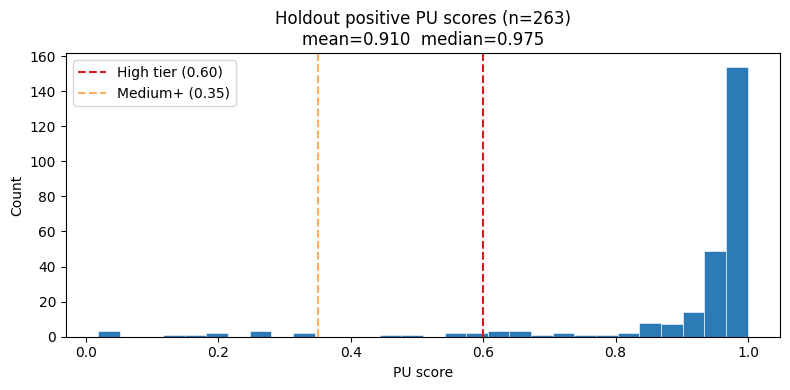

In [48]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(holdout_eval, bins=30, color='#2c7bb6', edgecolor='white', linewidth=0.4)
ax.axvline(0.60, color='#d7191c', linestyle='--', label='High tier (0.60)')
ax.axvline(0.35, color='#fdae61', linestyle='--', label='Medium+ (0.35)')
ax.set_xlabel('PU score')
ax.set_ylabel('Count')
ax.set_title(f'Holdout positive PU scores (n={len(holdout_eval)})\nmean={holdout_eval.mean():.3f}  median={np.median(holdout_eval):.3f}')
ax.legend()
plt.tight_layout()
plt.show()

In [49]:
holdout_df = pos_holdout.copy().reset_index(drop=True)
holdout_df['holdout_pu_score'] = holdout_eval

cols = [c for c in ['title', 'description', 'org_name', 'org_type'] if c in holdout_df.columns]

missed = holdout_df[holdout_df['holdout_pu_score'] < 0.35].sort_values('holdout_pu_score')
low_conf = holdout_df[(holdout_df['holdout_pu_score'] >= 0.35) & (holdout_df['holdout_pu_score'] < 0.60)].sort_values('holdout_pu_score')

print(f'False negatives — below Medium+ threshold (< 0.35):  {len(missed)}')
print(f'Low confidence — Medium tier (0.35–0.60):            {len(low_conf)}\n')

False negatives — below Medium+ threshold (< 0.35):  12
Low confidence — Medium tier (0.35–0.60):            6



In [50]:
display(missed[['holdout_pu_score'] + cols].head(20))

,holdout_pu_score,title,description,org_name,org_type
58,0.018374,FOIA Electronic Reading Room,The E-FOIA Amendments of 1996 require that fre...,US International Trade Commission,Federal Government
190,0.026044,"Metabolic Rate, Body Composition, Foraging Suc...",This data package includes 5 child items with ...,Department of the Interior,Federal Government
79,0.026674,FOIA Logs,Log files published by the Office of FOIA Serv...,Securities and Exchange Commission,Federal Government
204,0.127940,Dissolved Pesticides in Weekly Water Samples f...,Dissolved pesticides were measured in weekly w...,Department of the Interior,Federal Government
106,0.174087,dhds_dataset,This is a dataset manually created by Spiro Ts...,U.S. Department of Health & Human Services,Federal Government
243,0.196795,Permafrost greenhouse gas and microbial data f...,These data include permafrost gas concentratio...,Department of the Interior,Federal Government
261,0.206649,Trauma-Focused Psychotherapy for PTSD,Learn about studies of trauma-focused psychoth...,Department of Veterans Affairs,Federal Government
21,0.251940,Data and Associated Code for Projections of Un...,This data release includes data containing pro...,Department of the Interior,Federal Government
120,0.254466,Influenza A virus detected from bivalves in wa...,This data set includes information pertaining ...,Department of the Interior,Federal Government
179,0.263385,Data from simulations of ecological and hydrol...,This data release contains data discussed in i...,Department of the Interior,Federal Government
